# What complex rules add

In [1]:
import os
import sys
from dataclasses import replace

sys.path[:0] = [os.path.abspath("scripts"), os.path.abspath(".."), os.path.abspath("../differential_rules")]
import complex_investigation as ci
import complex_investigation_vis as vis
import complex_hypotheses as hypotheses
from IPython.display import display

In [2]:
CONFIG = ci.Config(
    max_items=4, support=0.01, expected_support=0.01, confidence=0.5,
    min_cells=20, min_fovs=5, min_patients=3, min_group_fovs=10,
    visible_gap=0.15, top_n=8, permutations=4999,
    score=os.environ.get("SCORE_COLUMN", "Clinical score"),
)
PREFIX = "overview_" + ("clin" if CONFIG.score.startswith("Clinical") else "path")

[C] marks the center; every other item is a neighbor. Rules retain their stored mining FDR and classification. Attraction requires the displayed observed support and confidence; avoidance uses expected support = Support − Leverage, including Lift = 0. Eligibility requires every named type in the FOV.

Stage tests reuse the differential permutation methods (fixed seed 0): FOV occurrence, biopsy mean, and patient mean of biopsy means. Cross-stage patients are omitted only from unpaired patient tests, never from plots. BH correction covers both organs, both rule states and all three contrasts plus the ordered trend within each analysis and unit. These exploratory screens are not independent validation. Patient FDR is evidence, not a mandatory display gate.

In [3]:
cells, metadata, rules = ci.load(CONFIG)

Dropped 21 FOVs: Control_S


Loaded 598093 cells; FOVs: 267, biopsies: 73, patients: 71


Read results_CN_pairwise.csv + results_CN_complex.csv


{'max_items': 4, 'min_cells': 20, 'mining_fdr': 0.05, 'support': 0.01, 'confidence': 0.5, 'expected_support': 0.01, 'score': 'Clinical score', 'min_fovs': 5, 'min_patients': 3, 'min_group_fovs': 10, 'visible_gap': 0.15, 'attraction_lift_gap': 0.3, 'avoidance_lift_gap': 0.15, 'permutations': 4999, 'top_n': 8}
690,345 stored center-specific occurrences; distinct cell types only
Mining settings: {'settings': {'weighting': 'binary', 'method': 'CN', 'radius': 25.0, 'min_support': 0.01, 'min_lift': 1.2, 'max_items_per_rule': 4, 'bandwidth': 15.0, 'k_neighbors': None, 'min_cells_per_patch': 2, 'max_one_type_share': 0.9, 'min_patches': 15, 'strong_confidence': 0.9, 'min_support_when_strong': 0.005, 'min_confidence': 0.5, 'min_leverage': 0.0005, 'min_conviction': 1.3, 'include_avoidance_rules': True, 'avoidance_max_lift': 0.8, 'avoidance_max_leverage': None, 'avoidance_min_expected_meetings': 30, 'min_label_count': 5, 'min_label_share': None, 'decay_distance': 15.0}, 'steps': {'n_shuffles': 100

In [4]:
analysis = ci.analyse(rules, cells, metadata, CONFIG)
recurrent = ci.candidates(analysis["counts"], analysis["tests"], CONFIG, purpose="recurrence")
gains = ci.gain_candidates(analysis, rules, metadata)
SPECS = ci.pd.concat([gains, recurrent]).drop_duplicates(["organ", "rule", "kind"]).reset_index(drop=True)
ci.save_tables(analysis, SPECS, PREFIX)
display(SPECS)

,organ,rule,kind,gain,matched_fovs,patients,stream,contrast,gap,patient_fdr,hits,eligible,share
0,Colon,Endothelial + Epithelial -> Goblet + SMV,attracts,0.965169,9.0,8,measured gain,Control–Severe,NaN,NaN,NaN,NaN,NaN
1,Duodenum,CD8T + Epithelial -> Goblet + Plasma,attracts,0.852403,5.0,4,measured gain,Control–Severe,NaN,NaN,NaN,NaN,NaN
2,Colon,Macrophage + Plasma -> Muscle,avoids,0.495639,7.0,5,measured gain,Control–Severe,NaN,NaN,NaN,NaN,NaN
3,Duodenum,Macrophage + Plasma -> Muscle,avoids,0.409767,7.0,6,measured gain,Control–Severe,NaN,NaN,NaN,NaN,NaN
4,Colon,Goblet -> CD8T + Macrophage,avoids,NaN,NaN,19,recurrence,Control–Mild,0.414545,0.674259,62.0,77.0,0.805195
5,Colon,Goblet -> CD4T + Macrophage,avoids,NaN,NaN,16,recurrence,Control–Severe,0.270270,0.674259,56.0,71.0,0.788732
6,Duodenum,Goblet -> Fibroblast + Macrophage,avoids,NaN,NaN,40,recurrence,Control–Severe,0.049275,0.956526,103.0,136.0,0.757353
7,Duodenum,Goblet -> CD4T + Macrophage,avoids,NaN,NaN,32,recurrence,Control–Severe,0.333333,0.703703,75.0,126.0,0.595238
8,Colon,Epithelial + Neuron -> Fibroblast + Goblet,attracts,NaN,NaN,13,recurrence,Mild–Severe,0.336207,0.897029,27.0,55.0,0.490909
9,Colon,Epithelial + Plasma -> Goblet + Macrophage,attracts,NaN,NaN,10,recurrence,Control–Severe,0.105455,1.000000,24.0,51.0,0.470588


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_attracts_classes.pdf


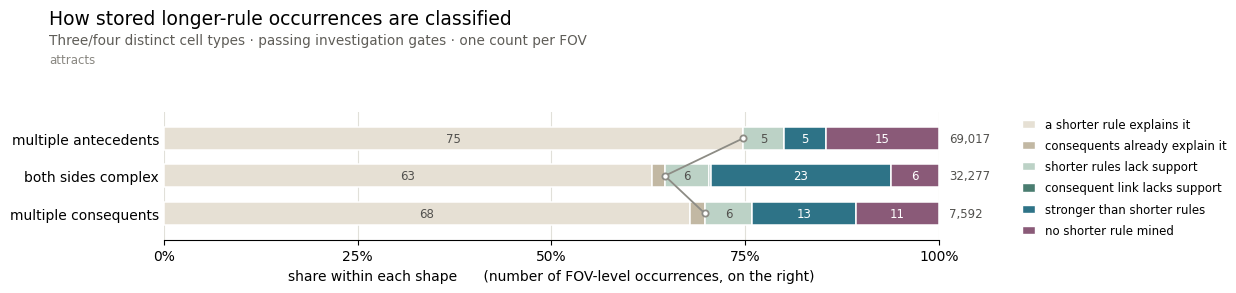

In [5]:
vis.show_classes("attracts", rules, CONFIG, PREFIX)

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_avoids_classes.pdf


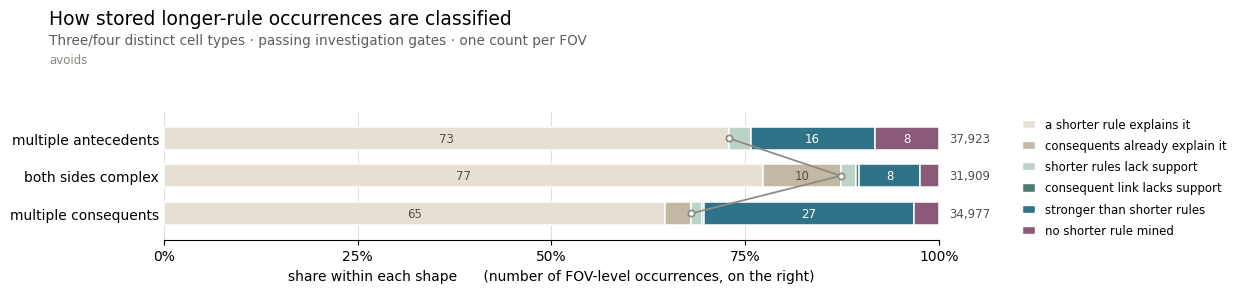

In [6]:
vis.show_classes("avoids", rules, CONFIG, PREFIX)

Each cell shows one automatically selected rule. Blue/red prevalence and Lift use eligible FOVs; the bottom bar also shows the ineligible fields. A missing shorter rule is not assigned an artificial gain.

In [7]:
def show_selected(index):
    vis.show_selected(index, SPECS, analysis, rules, cells, metadata, PREFIX,
                      parents=True, pooled=True)

**[0] Colon · Endothelial + Epithelial -> Goblet + SMV**

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,9,34,97,8,16
1,All,avoids,0,34,97,0,16
2,Control,attracts,2,15,25,2,4
3,Control,avoids,0,15,25,0,4
4,Mild,attracts,1,3,18,1,2
5,Mild,avoids,0,3,18,0,2
6,Severe,attracts,6,16,54,5,10
7,Severe,avoids,0,16,54,0,10


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_276326dad7_summary.pdf


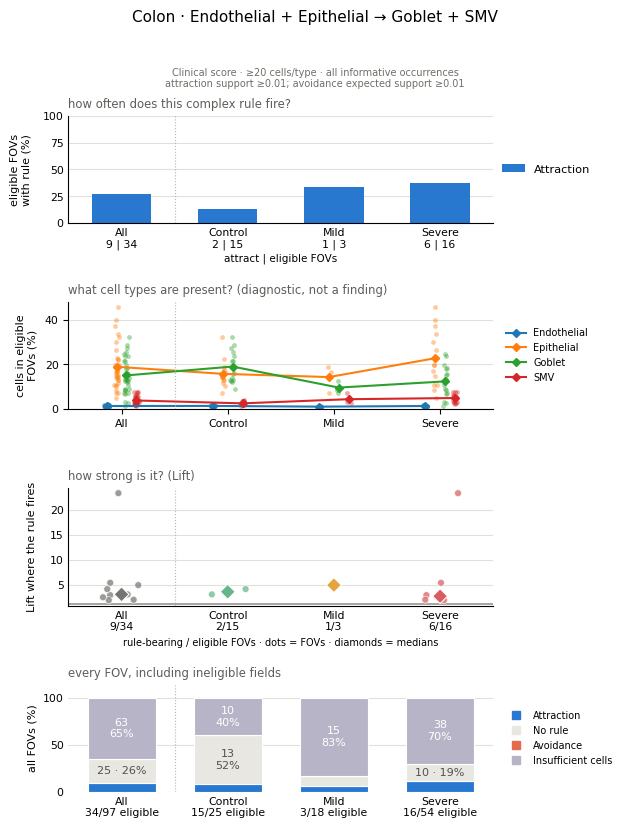

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_276326dad7_parent_prevalence.pdf


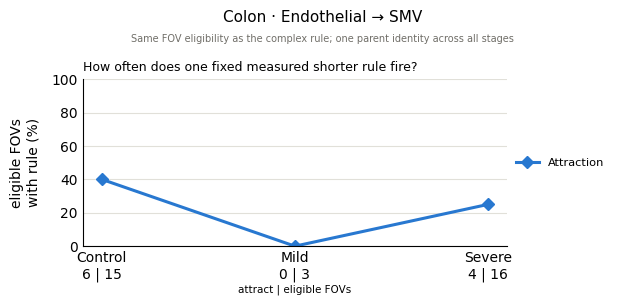

Fixed parent: Endothelial -> SMV; most often the best measured shorter rule in 4 matched FOVs.


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_276326dad7_parents.pdf


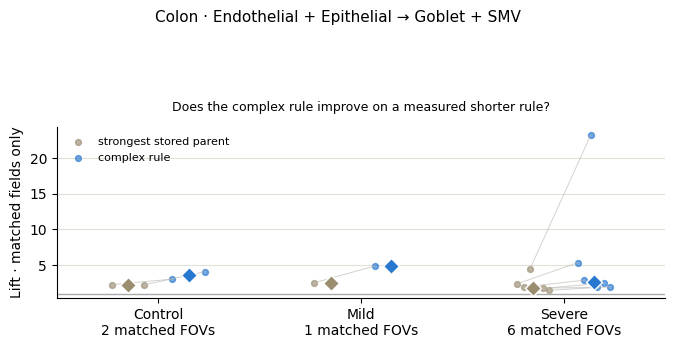

,matched_fovs,median_complex_lift,median_parent_lift,significant_parents
stage,,,,
Control,2,3.551969,2.229348,1
Severe,6,2.664612,1.830009,4
Mild,1,4.881623,2.511109,1


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_276326dad7_fovs.pdf


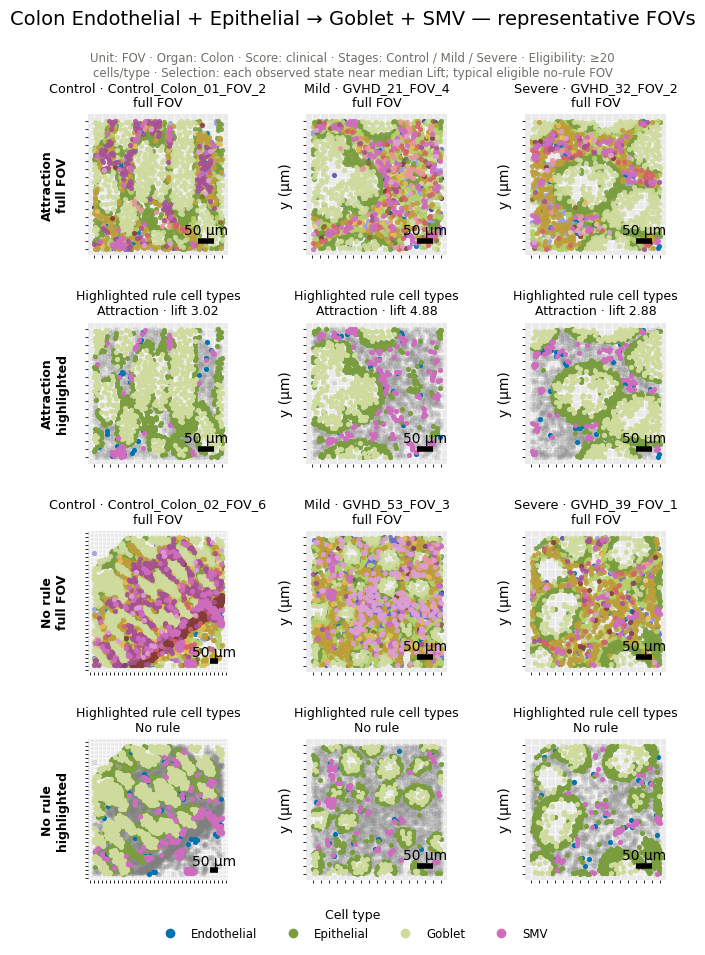

In [8]:
show_selected(0)

**[1] Duodenum · CD8T + Epithelial -> Goblet + Plasma**

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,5,79,170,4,31
1,All,avoids,0,79,170,0,31
2,Control,attracts,0,28,31,0,10
3,Control,avoids,0,28,31,0,10
4,Mild,attracts,4,35,98,3,15
5,Mild,avoids,0,35,98,0,15
6,Severe,attracts,1,16,41,1,6
7,Severe,avoids,0,16,41,0,6


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_75f281cb73_summary.pdf


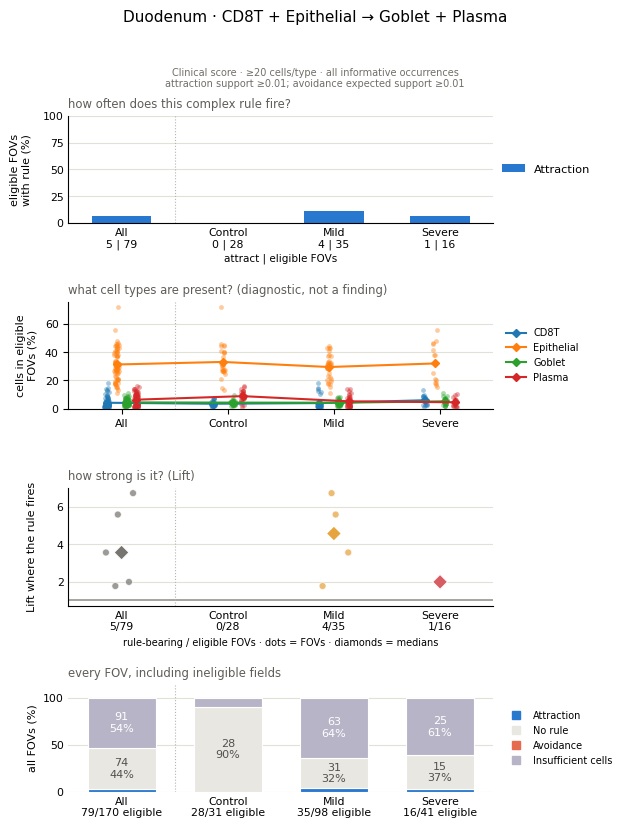

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_75f281cb73_parent_prevalence.pdf


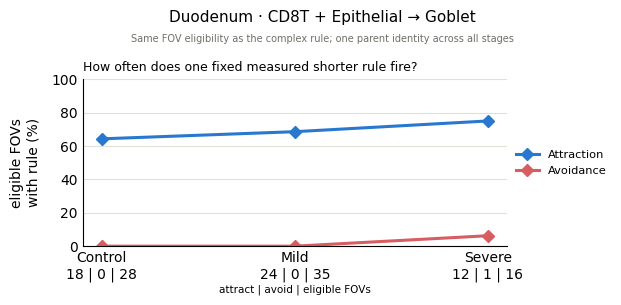

Fixed parent: CD8T + Epithelial -> Goblet; most often the best measured shorter rule in 4 matched FOVs.


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_75f281cb73_parents.pdf


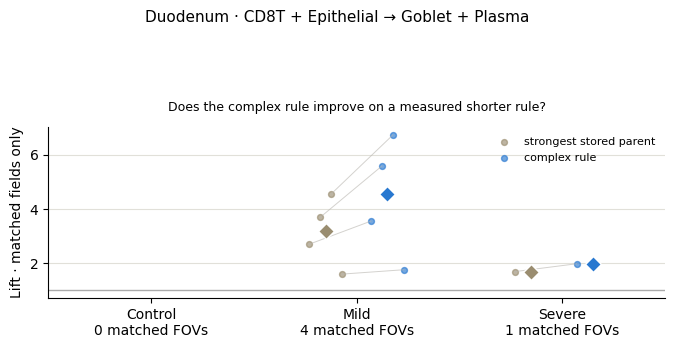

,matched_fovs,median_complex_lift,median_parent_lift,significant_parents
stage,,,,
Mild,4,4.571213,3.198877,4
Severe,1,1.979523,1.690706,1


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_75f281cb73_fovs.pdf


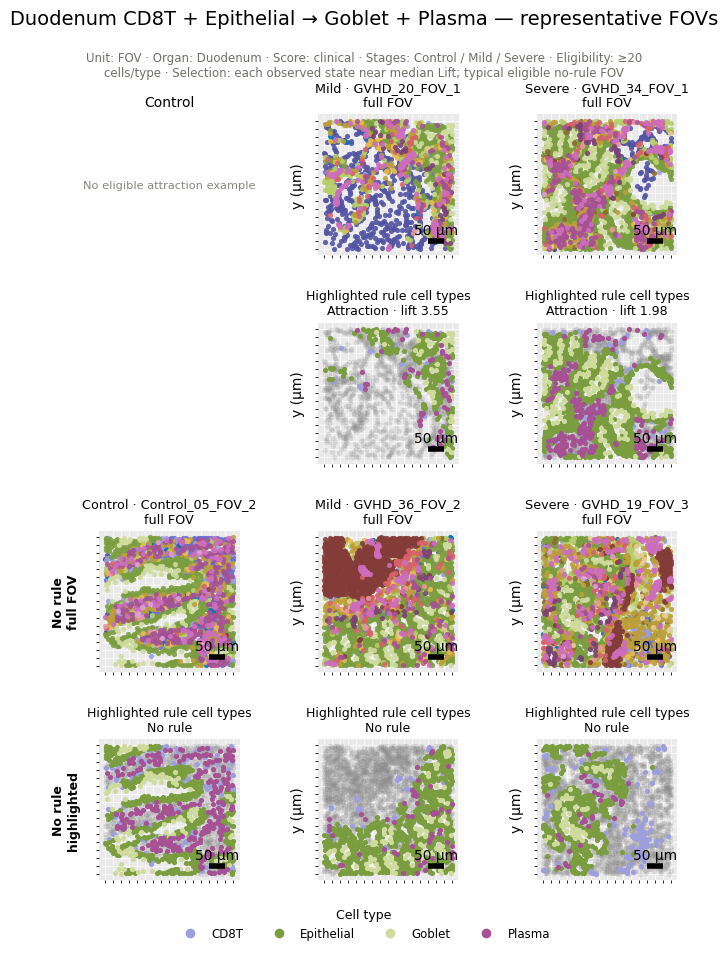

In [9]:
show_selected(1)

**[2] Colon · Macrophage + Plasma -> Muscle**

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,0,30,97,0,10
1,All,avoids,11,30,97,7,10
2,Control,attracts,0,20,25,0,4
3,Control,avoids,7,20,25,4,4
4,Mild,attracts,0,1,18,0,1
5,Mild,avoids,1,1,18,1,1
6,Severe,attracts,0,9,54,0,5
7,Severe,avoids,3,9,54,2,5


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_48a16be7e9_summary.pdf


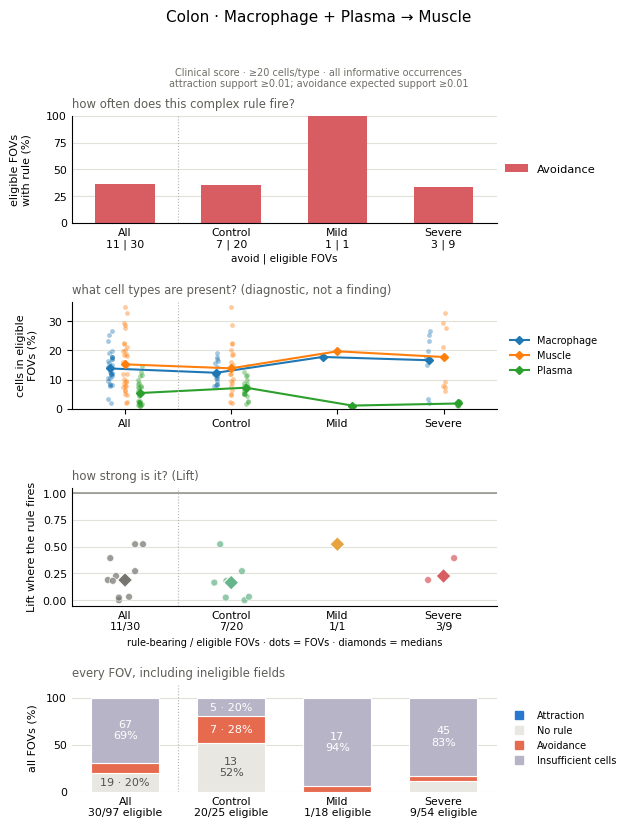

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_48a16be7e9_parent_prevalence.pdf


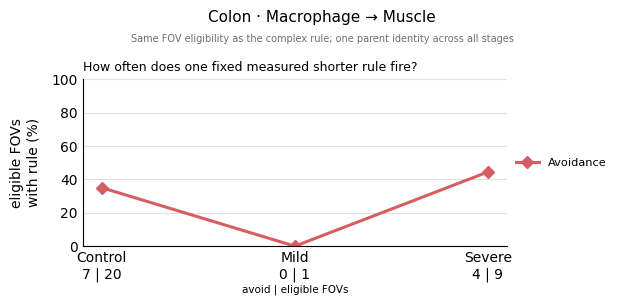

Fixed parent: Macrophage -> Muscle; most often the best measured shorter rule in 5 matched FOVs.


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_48a16be7e9_parents.pdf


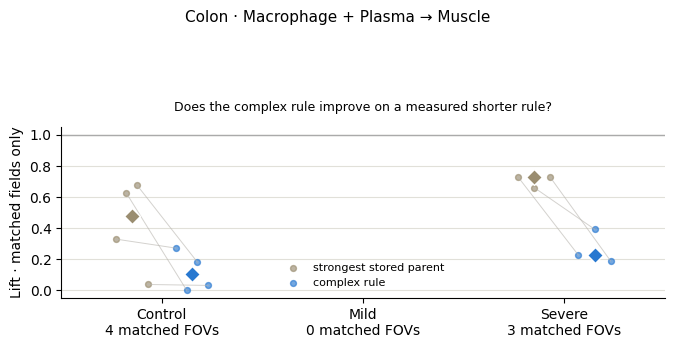

,matched_fovs,median_complex_lift,median_parent_lift,significant_parents
stage,,,,
Control,4,0.106143,0.477878,4
Severe,3,0.225744,0.727212,3


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_48a16be7e9_fovs.pdf


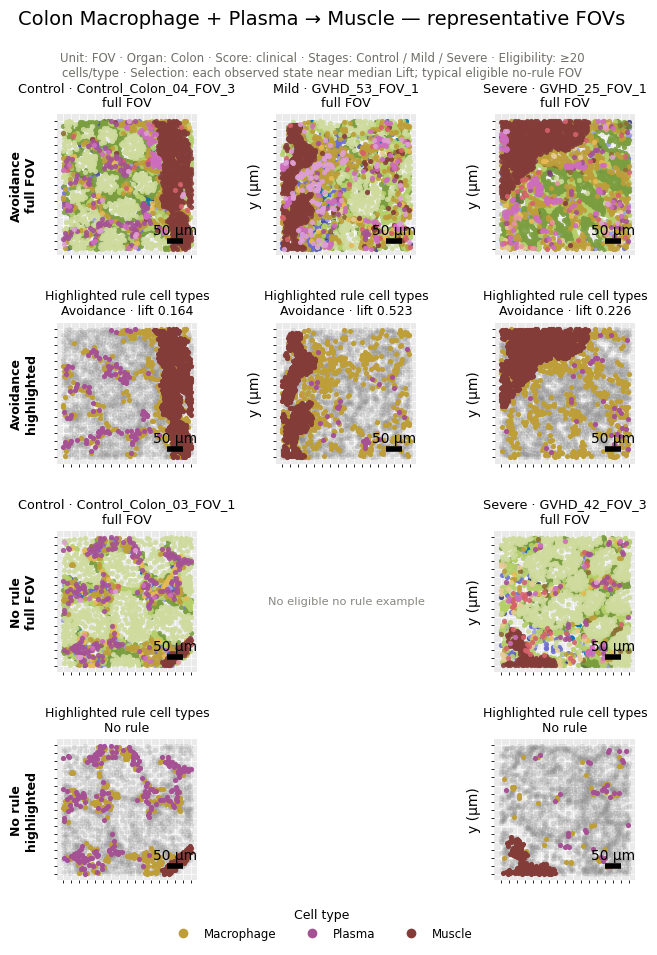

In [10]:
show_selected(2)

**[3] Duodenum · Macrophage + Plasma -> Muscle**

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,0,91,170,0,40
1,All,avoids,9,91,170,7,40
2,Control,attracts,0,17,31,0,8
3,Control,avoids,0,17,31,0,8
4,Mild,attracts,0,54,98,0,23
5,Mild,avoids,3,54,98,3,23
6,Severe,attracts,0,20,41,0,9
7,Severe,avoids,6,20,41,4,9


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_8dd10b5745_summary.pdf


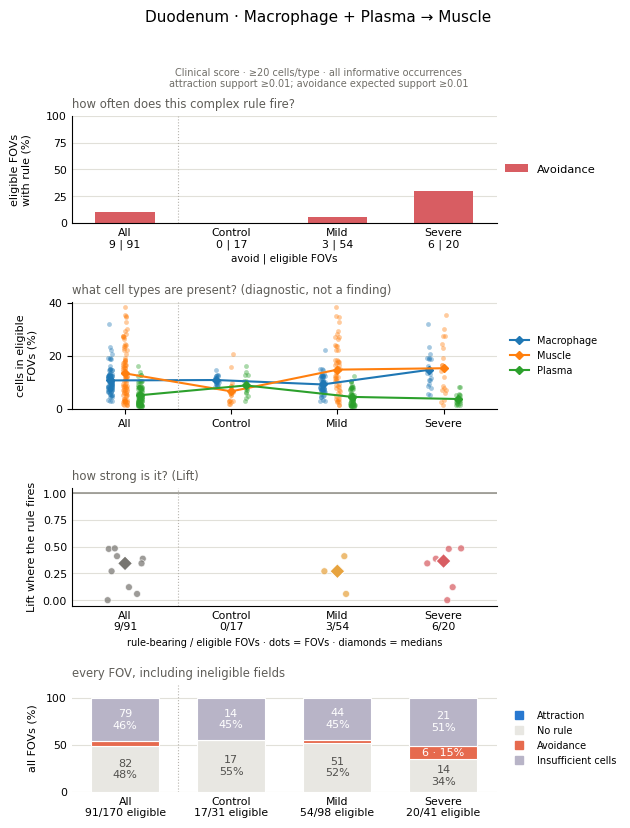

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_8dd10b5745_parent_prevalence.pdf


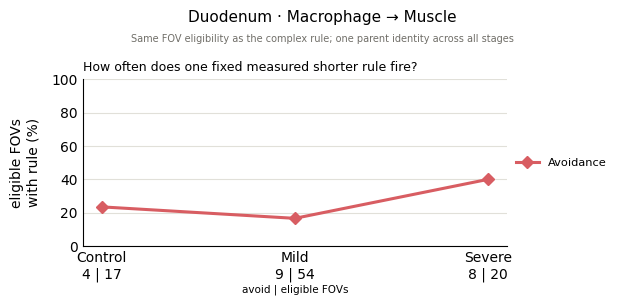

Fixed parent: Macrophage -> Muscle; most often the best measured shorter rule in 7 matched FOVs.


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_8dd10b5745_parents.pdf


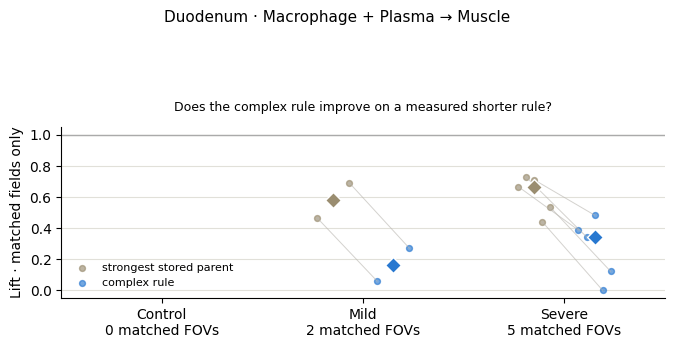

,matched_fovs,median_complex_lift,median_parent_lift,significant_parents
stage,,,,
Mild,2,0.164468,0.580908,2
Severe,5,0.343857,0.668059,5


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_8dd10b5745_fovs.pdf


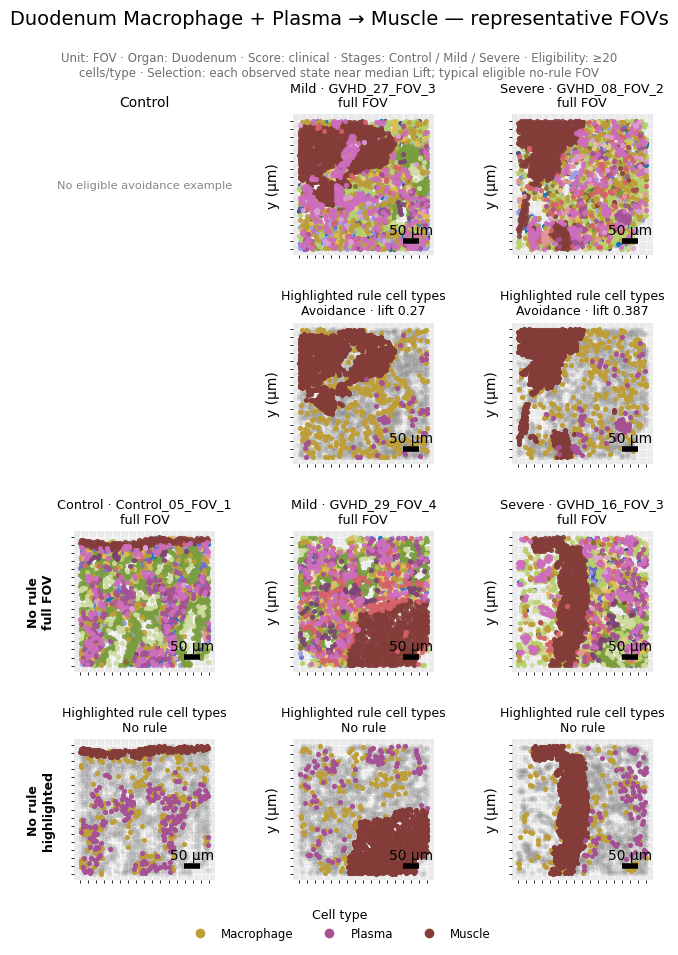

In [11]:
show_selected(3)

**[4] Colon · Goblet -> CD8T + Macrophage**

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,0,77,97,0,19
1,All,avoids,62,77,97,19,19
2,Control,attracts,0,25,25,0,4
3,Control,avoids,24,25,25,4,4
4,Mild,attracts,0,11,18,0,3
5,Mild,avoids,6,11,18,3,3
6,Severe,attracts,0,41,54,0,12
7,Severe,avoids,32,41,54,12,12


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_3e21af8591_summary.pdf


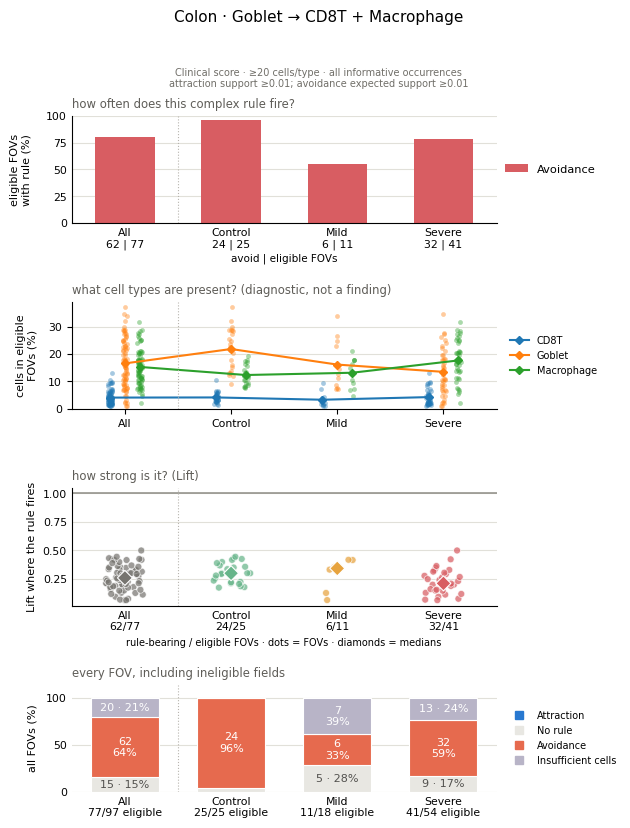

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_3e21af8591_parent_prevalence.pdf


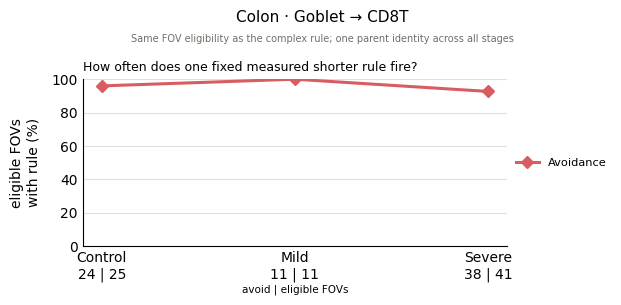

Fixed parent: Goblet -> CD8T; most often the best measured shorter rule in 38 matched FOVs.


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_3e21af8591_parents.pdf


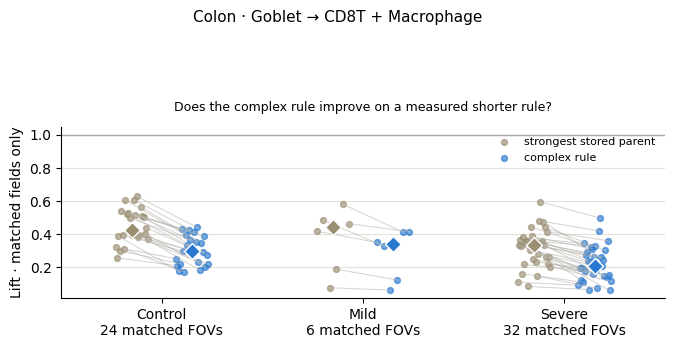

,matched_fovs,median_complex_lift,median_parent_lift,significant_parents
stage,,,,
Control,24,0.297258,0.427931,24
Severe,32,0.208416,0.336724,32
Mild,6,0.339990,0.440721,6


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_3e21af8591_fovs.pdf


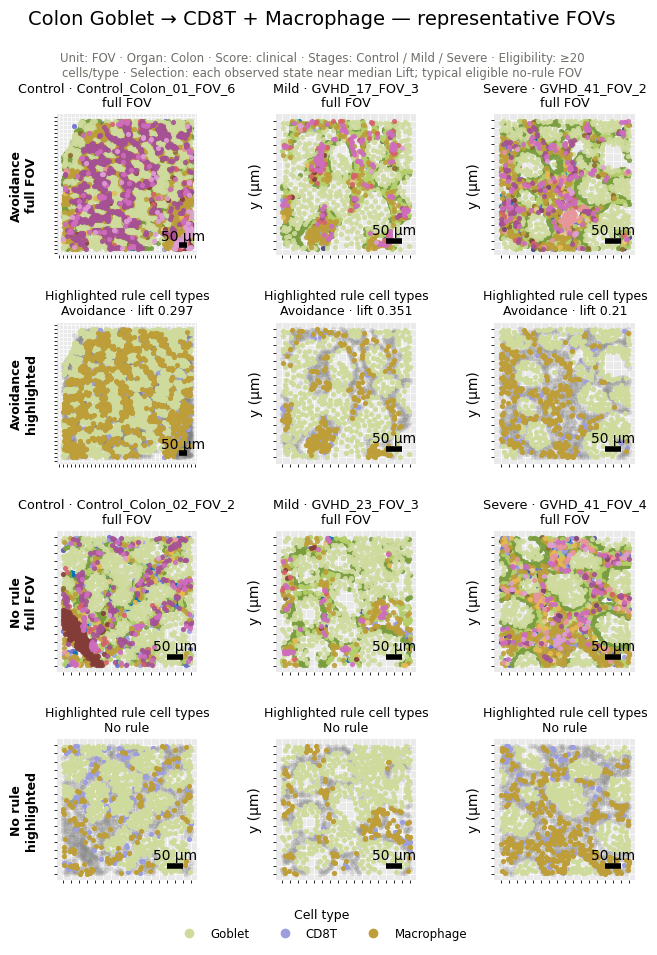

In [12]:
show_selected(4)

**[5] Colon · Goblet -> CD4T + Macrophage**

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,0,71,97,0,18
1,All,avoids,56,71,97,16,18
2,Control,attracts,0,25,25,0,4
3,Control,avoids,25,25,25,4,4
4,Mild,attracts,0,9,18,0,3
5,Mild,avoids,4,9,18,2,3
6,Severe,attracts,0,37,54,0,11
7,Severe,avoids,27,37,54,10,11


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_5cb52cff60_summary.pdf


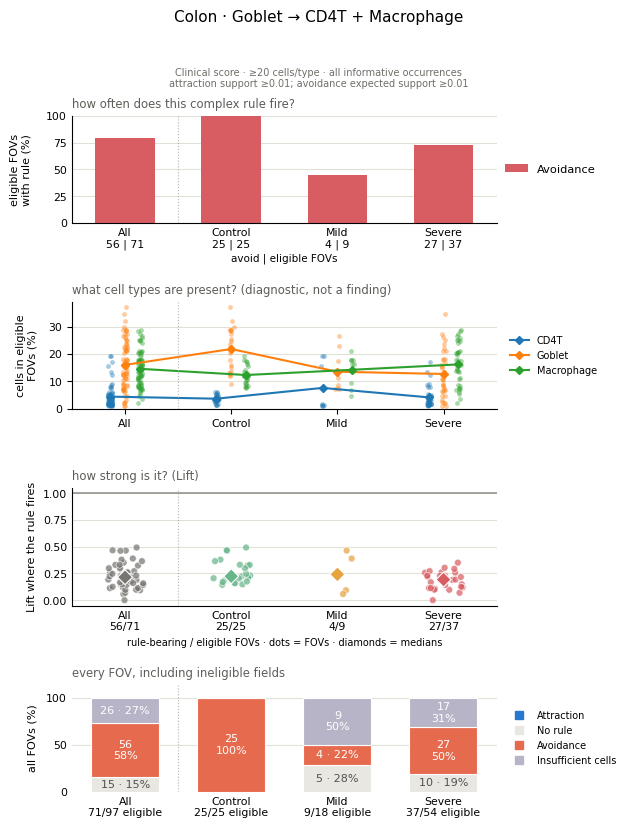

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_5cb52cff60_parent_prevalence.pdf


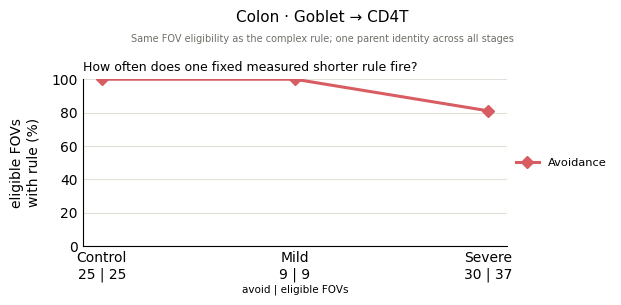

Fixed parent: Goblet -> CD4T; most often the best measured shorter rule in 52 matched FOVs.


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_5cb52cff60_parents.pdf


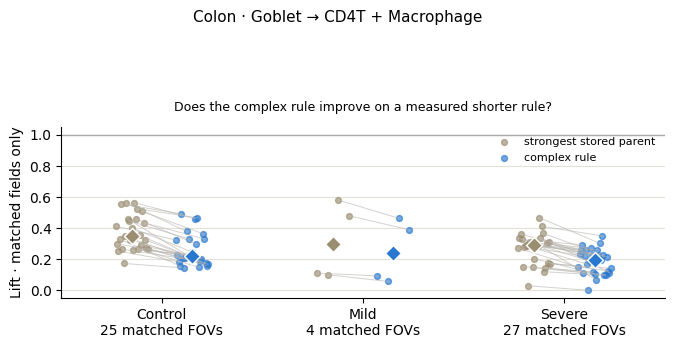

,matched_fovs,median_complex_lift,median_parent_lift,significant_parents
stage,,,,
Control,25,0.223229,0.346425,25
Severe,27,0.192612,0.290370,27
Mild,4,0.241098,0.295333,4


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_5cb52cff60_fovs.pdf


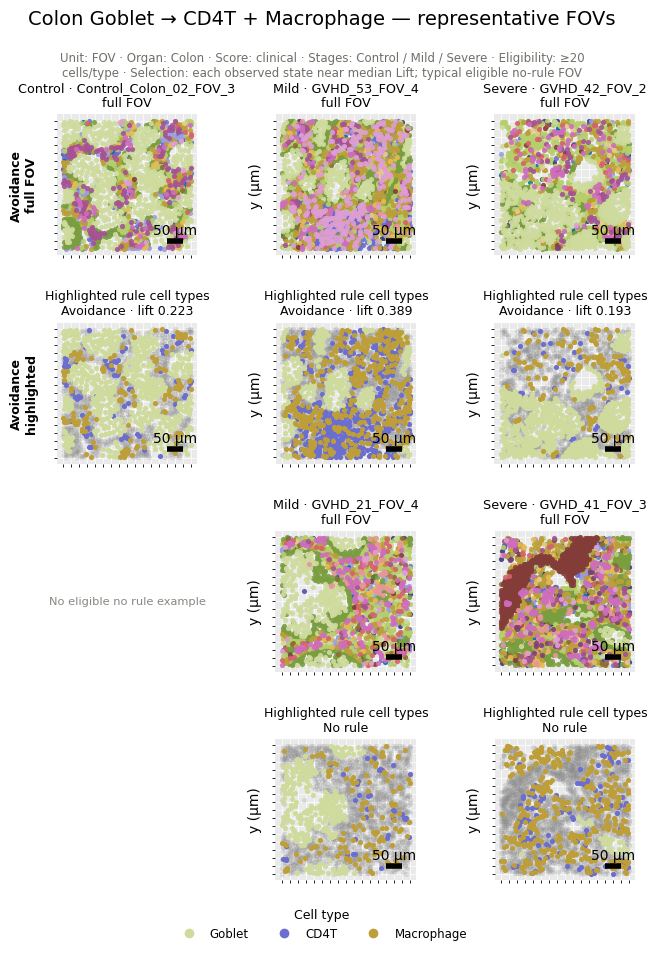

In [13]:
show_selected(5)

**[6] Duodenum · Goblet -> Fibroblast + Macrophage**

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,0,136,170,0,43
1,All,avoids,103,136,170,40,43
2,Control,attracts,0,30,31,0,10
3,Control,avoids,22,30,31,10,10
4,Mild,attracts,0,83,98,0,26
5,Mild,avoids,63,83,98,23,26
6,Severe,attracts,0,23,41,0,7
7,Severe,avoids,18,23,41,7,7


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_539c9a09e7_summary.pdf


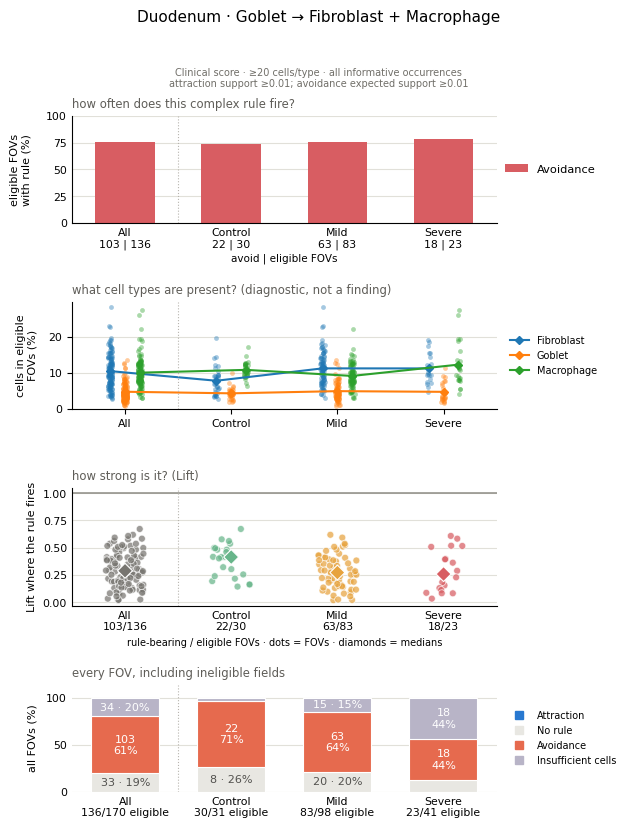

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_539c9a09e7_parent_prevalence.pdf


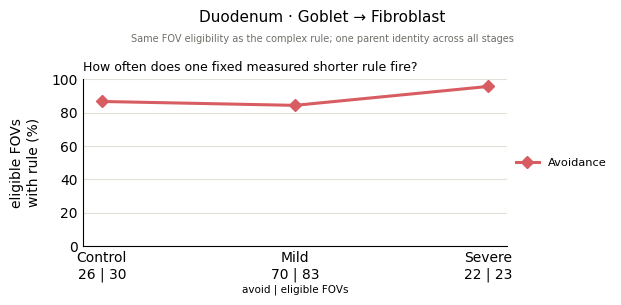

Fixed parent: Goblet -> Fibroblast; most often the best measured shorter rule in 58 matched FOVs.


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_539c9a09e7_parents.pdf


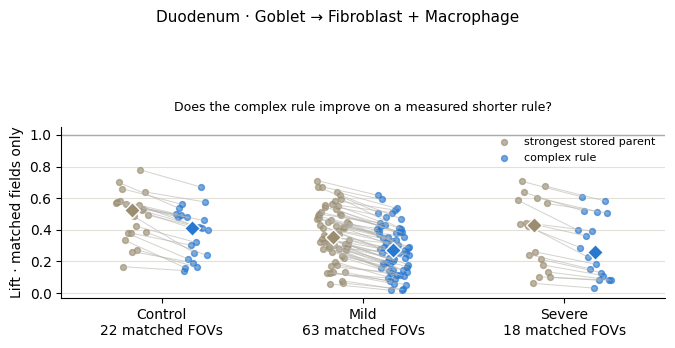

,matched_fovs,median_complex_lift,median_parent_lift,significant_parents
stage,,,,
Control,22,0.413617,0.527185,22
Mild,63,0.271304,0.356708,63
Severe,18,0.257628,0.432774,18


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_539c9a09e7_fovs.pdf


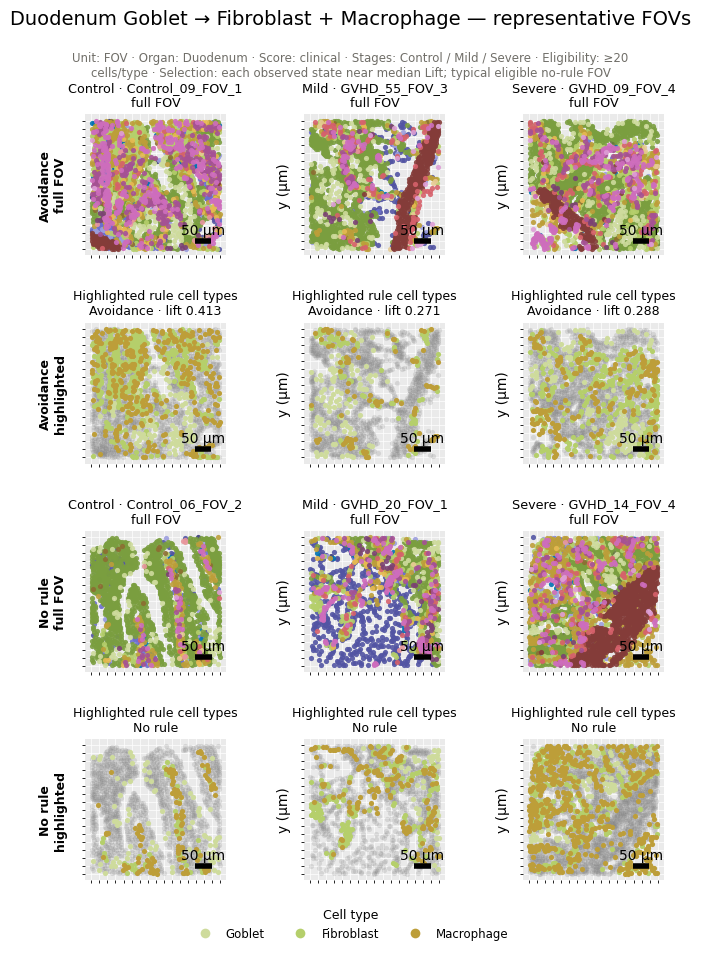

In [14]:
show_selected(6)

**[7] Duodenum · Goblet -> CD4T + Macrophage**

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,0,126,170,0,41
1,All,avoids,75,126,170,32,41
2,Control,attracts,0,30,31,0,10
3,Control,avoids,20,30,31,10,10
4,Mild,attracts,0,75,98,0,24
5,Mild,avoids,48,75,98,18,24
6,Severe,attracts,0,21,41,0,7
7,Severe,avoids,7,21,41,4,7


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_2458d5c779_summary.pdf


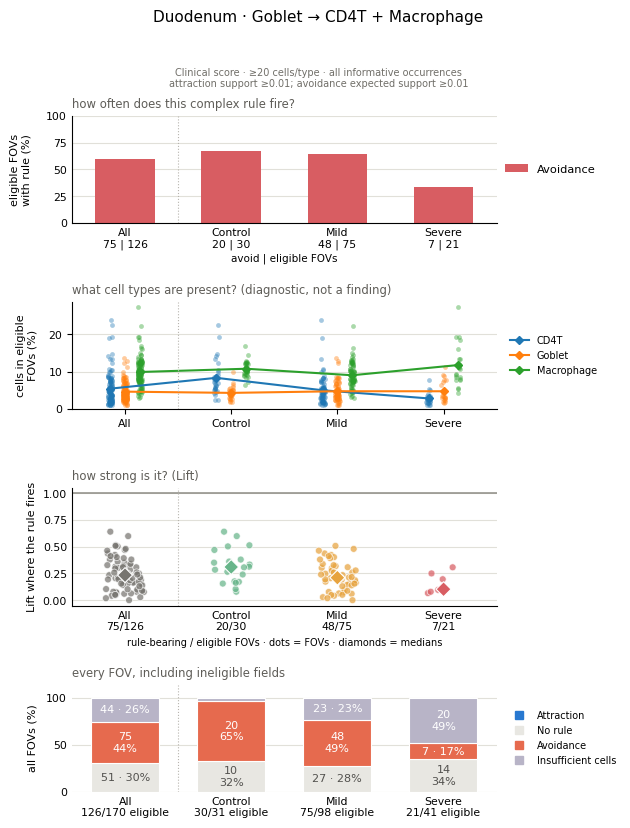

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_2458d5c779_parent_prevalence.pdf


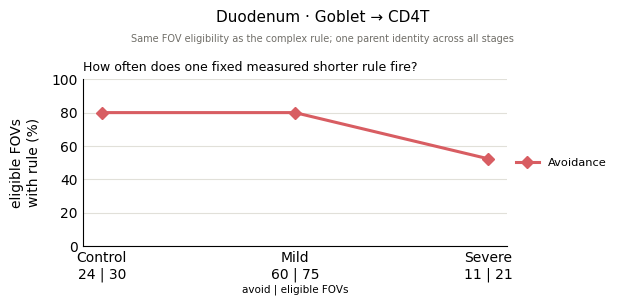

Fixed parent: Goblet -> CD4T; most often the best measured shorter rule in 50 matched FOVs.


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_2458d5c779_parents.pdf


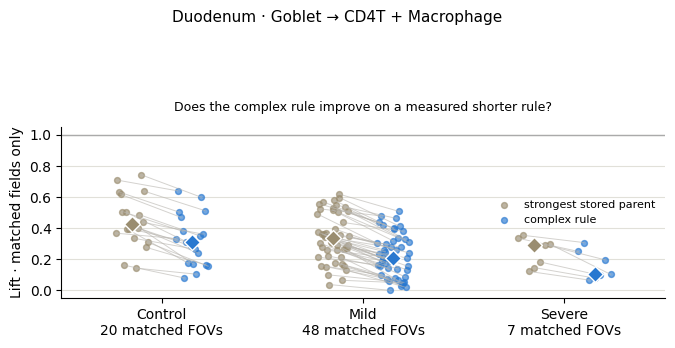

,matched_fovs,median_complex_lift,median_parent_lift,significant_parents
stage,,,,
Control,20,0.309961,0.424205,20
Mild,48,0.210397,0.336764,47
Severe,7,0.102408,0.294105,7


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_2458d5c779_fovs.pdf


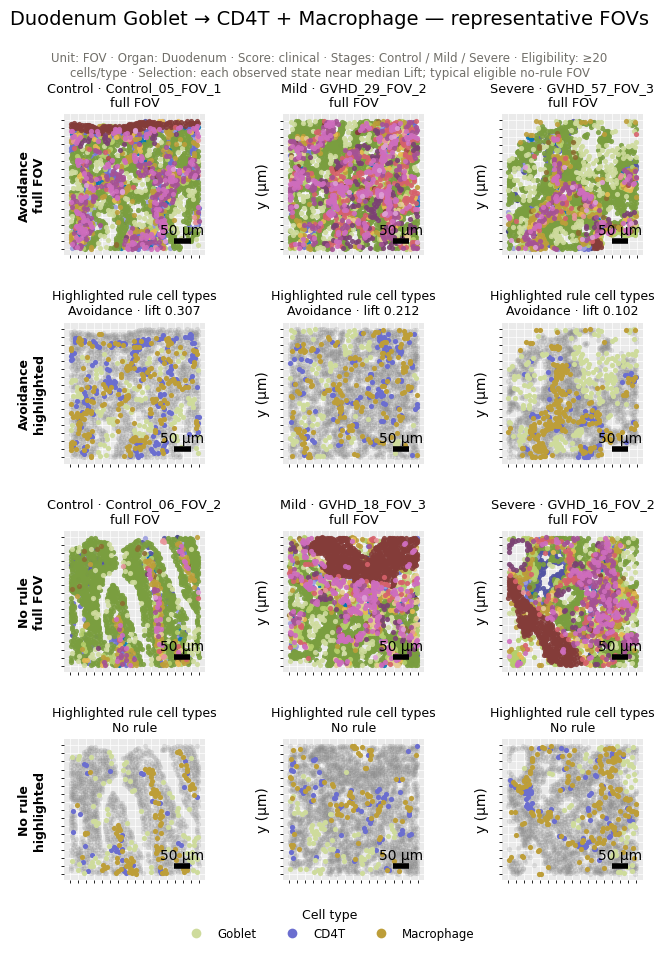

In [15]:
show_selected(7)

**[8] Colon · Epithelial + Neuron -> Fibroblast + Goblet**

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,27,55,97,13,20
1,All,avoids,0,55,97,0,20
2,Control,attracts,6,14,25,3,4
3,Control,avoids,0,14,25,0,4
4,Mild,attracts,9,12,18,3,4
5,Mild,avoids,0,12,18,0,4
6,Severe,attracts,12,29,54,7,12
7,Severe,avoids,0,29,54,0,12


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_61c04a50b1_summary.pdf


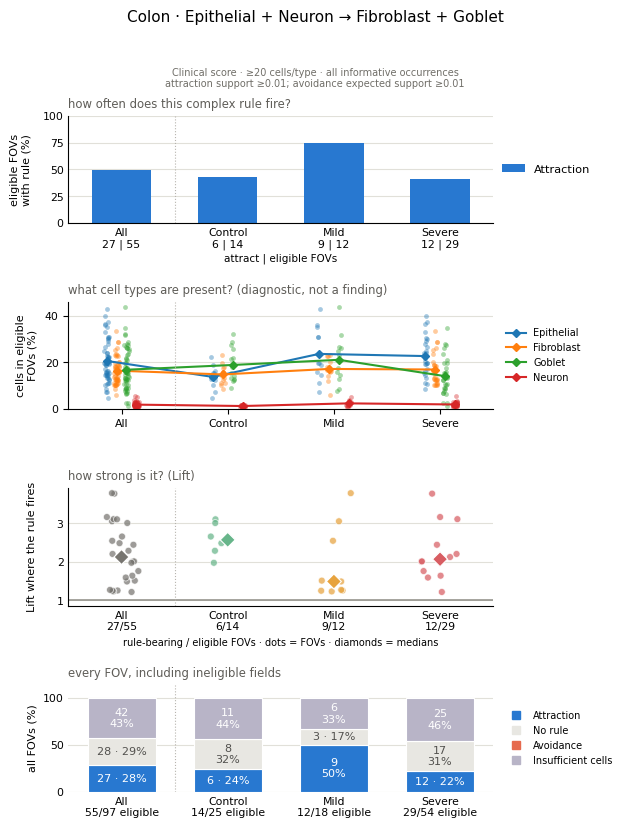

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_61c04a50b1_parent_prevalence.pdf


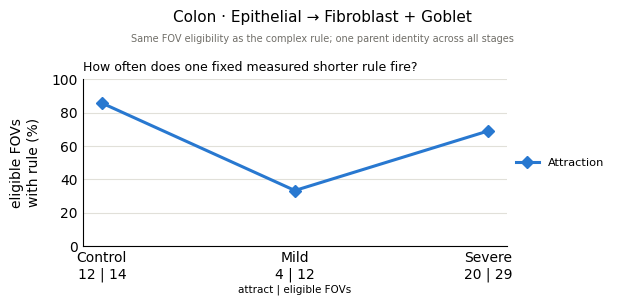

Fixed parent: Epithelial -> Fibroblast + Goblet; most often the best measured shorter rule in 15 matched FOVs.


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_61c04a50b1_parents.pdf


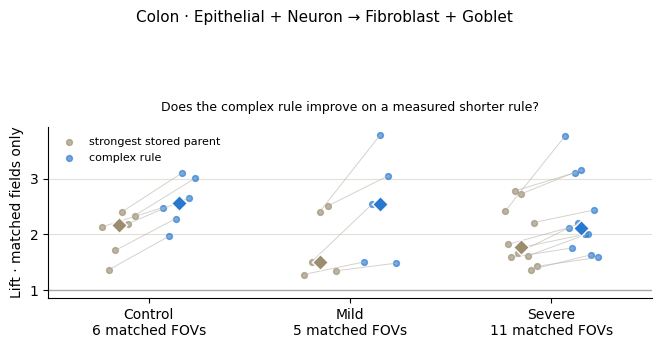

,matched_fovs,median_complex_lift,median_parent_lift,significant_parents
stage,,,,
Control,6,2.569181,2.166633,6
Severe,11,2.122581,1.777870,11
Mild,5,2.544406,1.515291,5


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_61c04a50b1_fovs.pdf


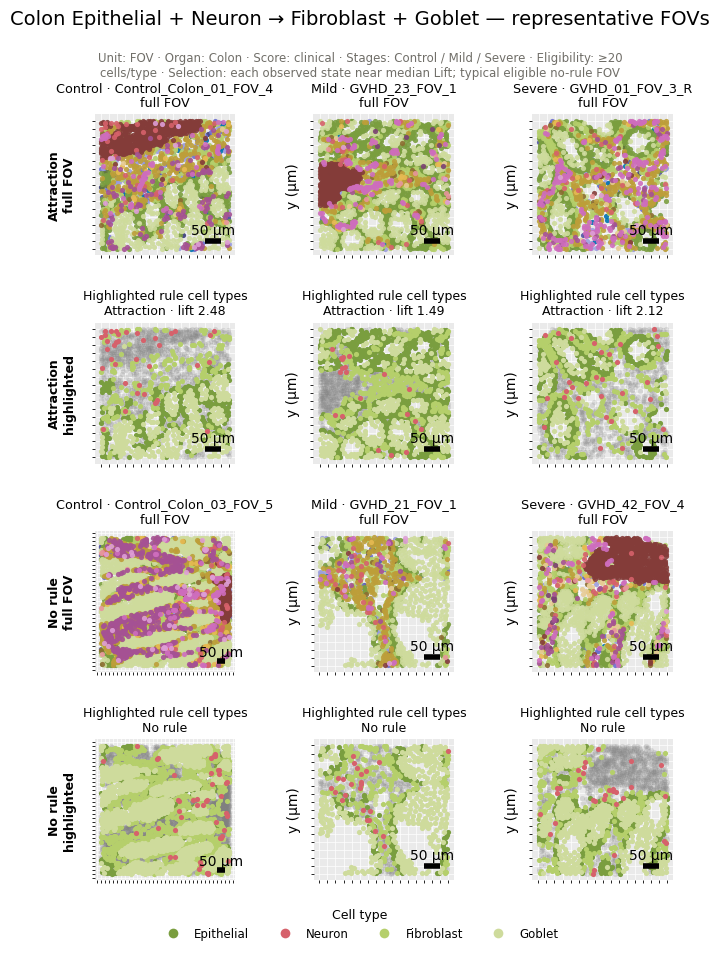

In [16]:
show_selected(8)

**[9] Colon · Epithelial + Plasma -> Goblet + Macrophage**

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,24,51,97,10,14
1,All,avoids,0,51,97,0,14
2,Control,attracts,11,25,25,4,4
3,Control,avoids,0,25,25,0,4
4,Mild,attracts,1,4,18,1,2
5,Mild,avoids,0,4,18,0,2
6,Severe,attracts,12,22,54,5,8
7,Severe,avoids,0,22,54,0,8


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_6cb401e214_summary.pdf


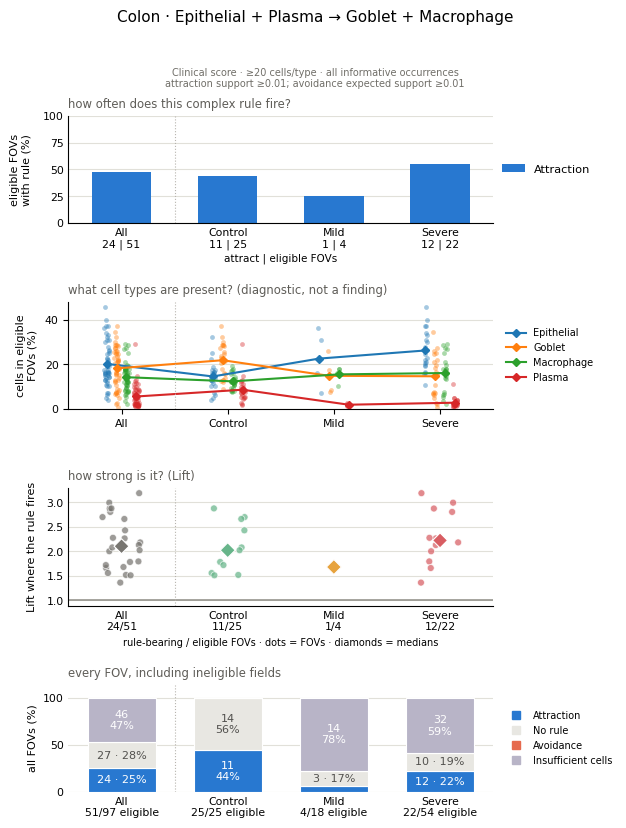

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_6cb401e214_parent_prevalence.pdf


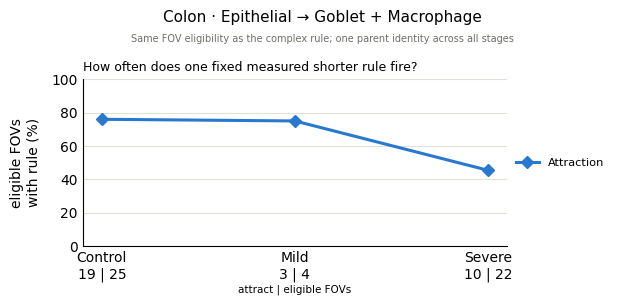

Fixed parent: Epithelial -> Goblet + Macrophage; most often the best measured shorter rule in 11 matched FOVs.


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_6cb401e214_parents.pdf


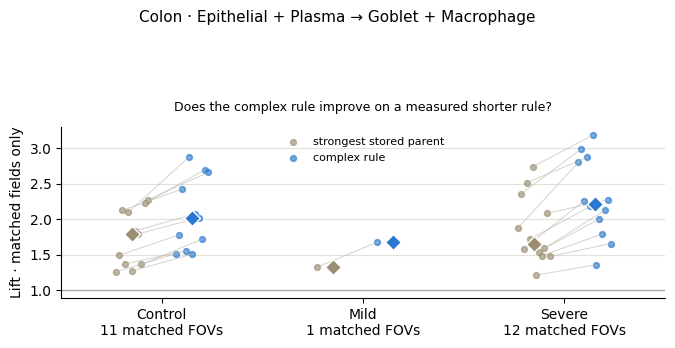

,matched_fovs,median_complex_lift,median_parent_lift,significant_parents
stage,,,,
Control,11,2.019955,1.794192,11
Severe,12,2.220658,1.654814,9
Mild,1,1.677219,1.324642,1


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_6cb401e214_fovs.pdf


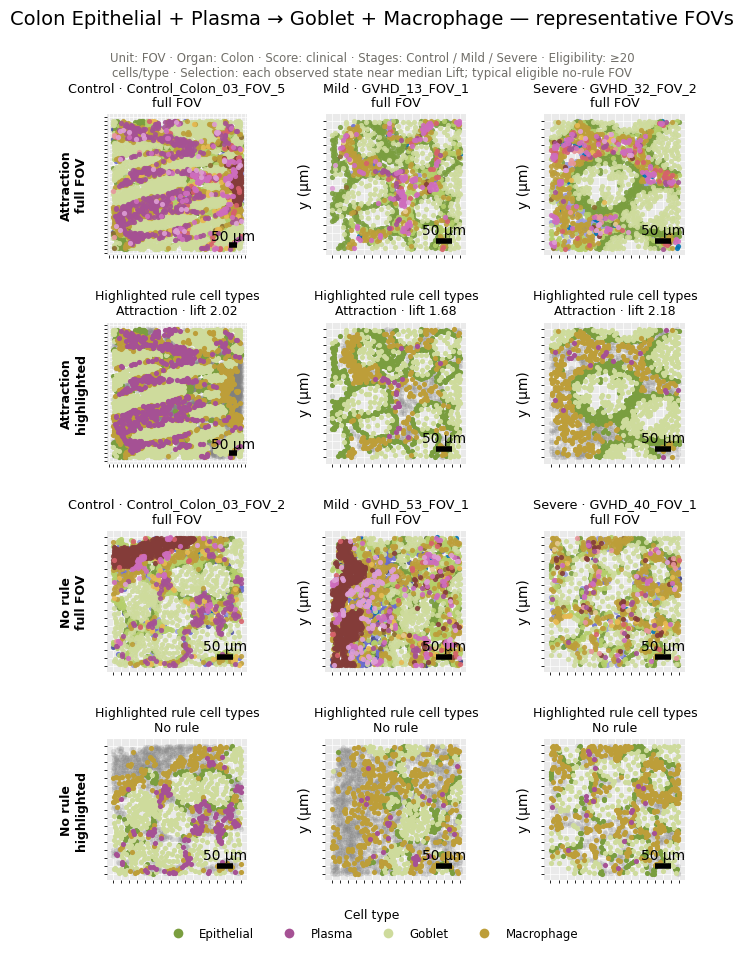

In [17]:
show_selected(9)

**[10] Duodenum · Epithelial + Plasma_CD38 -> Goblet + Plasma**

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,30,98,170,19,36
1,All,avoids,0,98,170,0,36
2,Control,attracts,8,27,31,6,9
3,Control,avoids,0,27,31,0,9
4,Mild,attracts,15,52,98,8,20
5,Mild,avoids,0,52,98,0,20
6,Severe,attracts,7,19,41,5,7
7,Severe,avoids,0,19,41,0,7


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_da050e5c17_summary.pdf


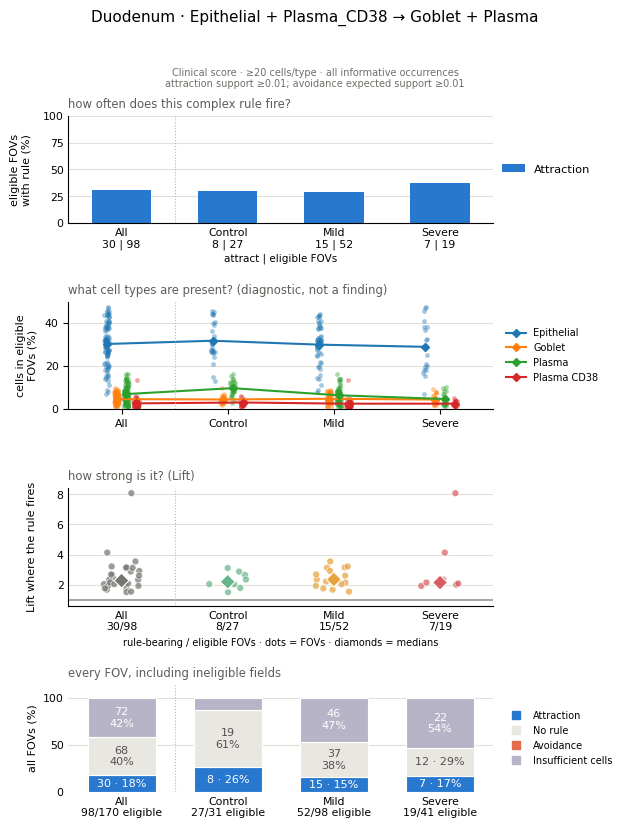

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_da050e5c17_parent_prevalence.pdf


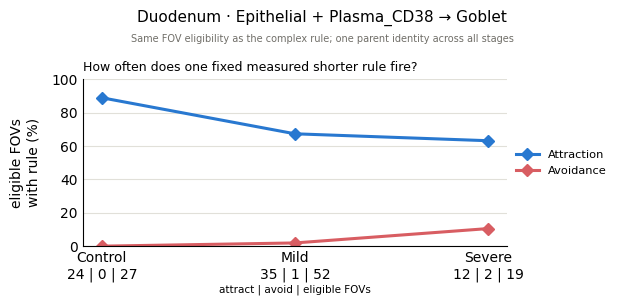

Fixed parent: Epithelial + Plasma_CD38 -> Goblet; most often the best measured shorter rule in 13 matched FOVs.


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_da050e5c17_parents.pdf


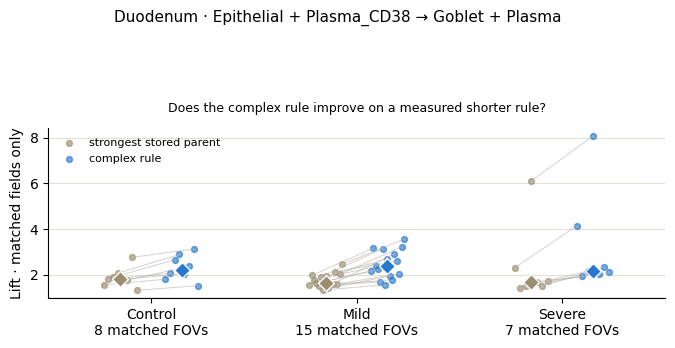

,matched_fovs,median_complex_lift,median_parent_lift,significant_parents
stage,,,,
Control,8,2.216199,1.800621,7
Severe,7,2.163847,1.690706,5
Mild,15,2.368121,1.631787,13


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_da050e5c17_fovs.pdf


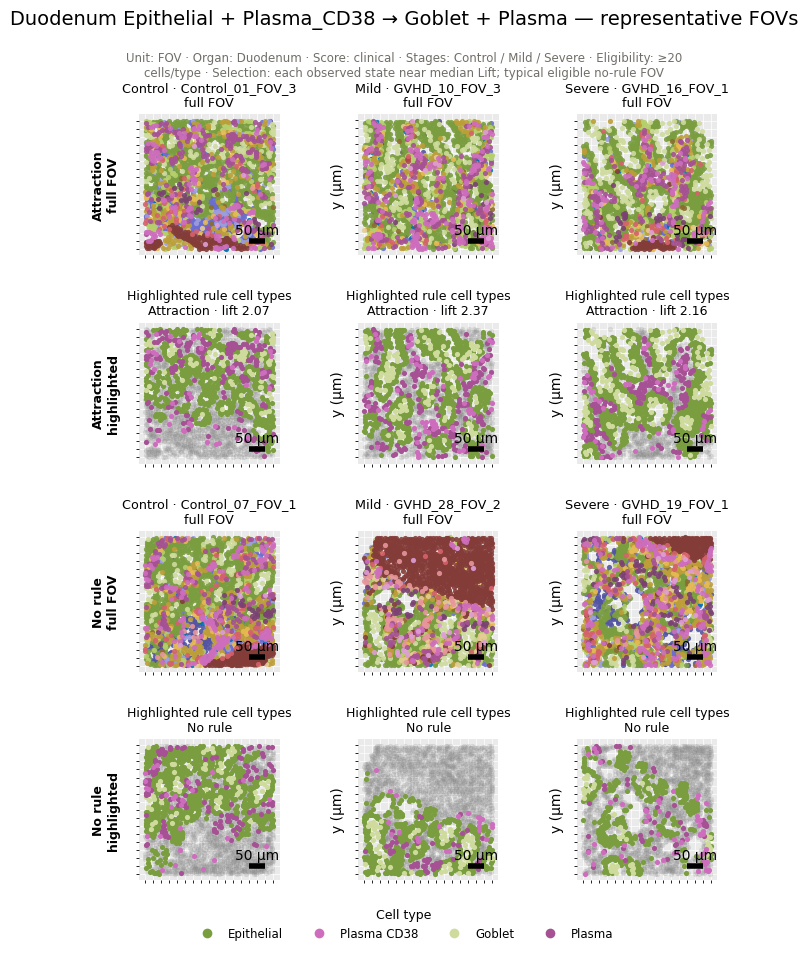

In [18]:
show_selected(10)

**[11] Duodenum · Endocrine + Fibroblast -> Epithelial + Macrophage**

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,11,37,170,7,16
1,All,avoids,0,37,170,0,16
2,Control,attracts,0,0,31,0,0
3,Control,avoids,0,0,31,0,0
4,Mild,attracts,9,29,98,6,13
5,Mild,avoids,0,29,98,0,13
6,Severe,attracts,2,8,41,1,3
7,Severe,avoids,0,8,41,0,3


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_1bec8614ba_summary.pdf


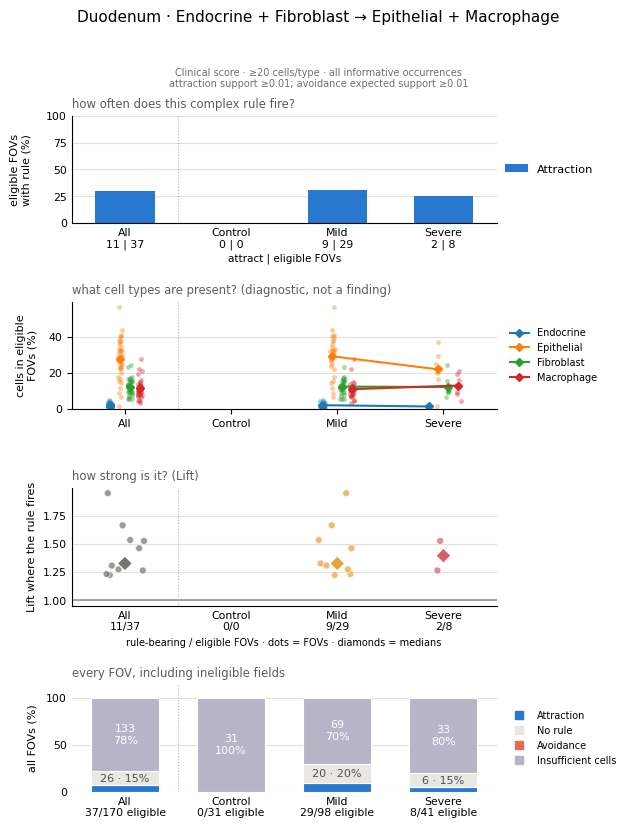

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_1bec8614ba_parent_prevalence.pdf


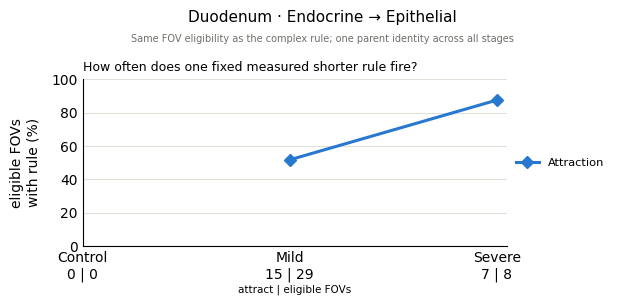

Fixed parent: Endocrine -> Epithelial; most often the best measured shorter rule in 4 matched FOVs.


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_1bec8614ba_parents.pdf


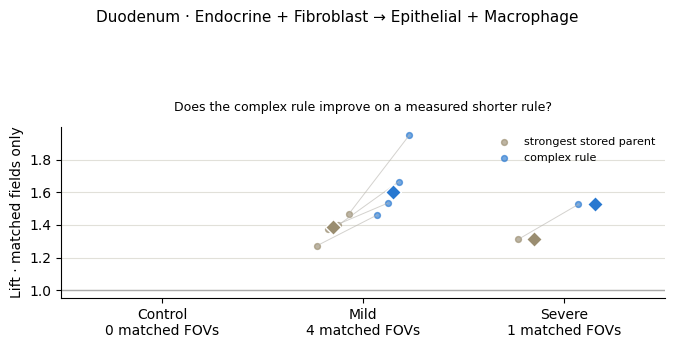

,matched_fovs,median_complex_lift,median_parent_lift,significant_parents
stage,,,,
Mild,4,1.599335,1.388384,3
Severe,1,1.526138,1.311274,1


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_1bec8614ba_fovs.pdf


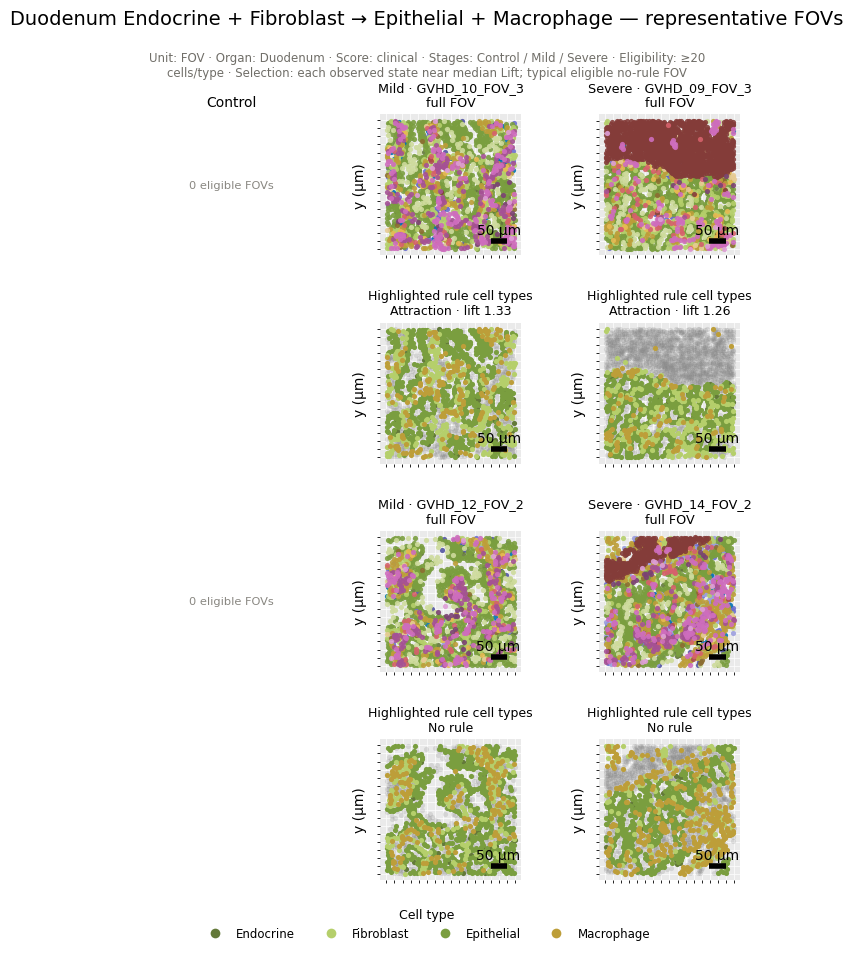

In [19]:
show_selected(11)

All stage-test results and denominators are saved beside the figures as CSV files. Change the configuration and rerun all cells; indexed cells outside the selected table safely print a note.